### Problem Definition
- **What problem are we solving?** Diagnosing the presence of heart disease in patients based on clinical metrics.
- **Why is this problem important?** Early detection saves lives.
- **What type of ML problem is this?** Supervised Binary Classification.

---

### Dataset
- **What information does this dataset contain?** Clinical metrics (cholesterol, max heart rate, chest pain type).
- **What is the target?** Target (1 = Heart Disease, 0 = Healthy).

In [2]:
import pandas as pd

df = pd.read_csv('./data/heart_disease_uci.csv')

In [3]:
import pandas as pd

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df.isna().sum())
print(df[df.duplicated(keep=False)].count())

print('\nDuplicates')
df.drop_duplicates(inplace=True)
print(df[df.duplicated(keep=False)])

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
<class '

In [4]:
import numpy as np

# Fix drop
df.drop(columns='ca', inplace=True)

# thal — you have this right
df['thal'] = df['thal'].fillna(value='normal')

# slope — mode impute
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])

# fbs — mode impute (0 or 1)
df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])

# restecg — mode impute
df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])

# exang — mode impute
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])

# trestbps — mean impute
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].mean())

# chol — mean impute
df['chol'] = df['chol'].fillna(df['chol'].mean())

# oldpeak — mean impute
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].mean())

# thalach — mode impute
df['thalch'] = df['thalch'].fillna(df['thalch'].mode()[0])

# Verify
print(df.isnull().sum())
print(df.shape)

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64
(920, 15)


C:\Users\DHRUV\AppData\Local\Temp\ipykernel_22296\1367925652.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
C:\Users\DHRUV\AppData\Local\Temp\ipykernel_22296\1367925652.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].fillna(df['exang'].mode()[0])


     Count  Percentage (%)
num                       
0      411       44.673913
1      265       28.804348
2      109       11.847826
3      107       11.630435
4       28        3.043478


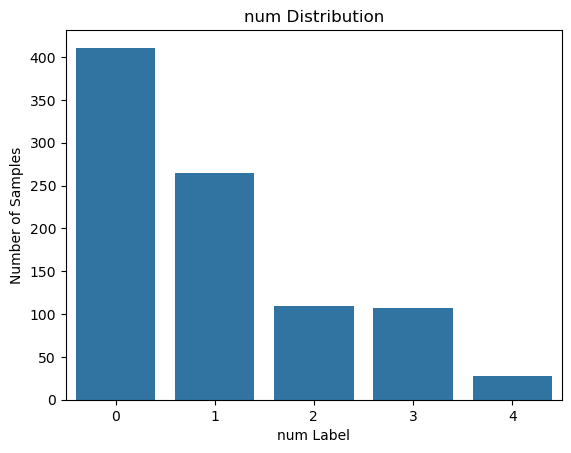

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['num'].value_counts()
percentages = df['num'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(imbalance_summary)

sns.countplot(x='num', data=df)
plt.title('num Distribution')
plt.xlabel('num Label')
plt.ylabel('Number of Samples')
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

In [6]:
print((df['age'] < 20).value_counts())


df['age_range'] = pd.cut(
    df['age'], 
    bins=[0, 40, 55, 120], 
    labels=['adult', 'middle_age', 'senior'],
    include_lowest=True)

print(df[['age', 'age_range']])

age
False    920
Name: count, dtype: int64
     age   age_range
0     63      senior
1     67      senior
2     67      senior
3     37       adult
4     41  middle_age
..   ...         ...
915   54  middle_age
916   62      senior
917   55  middle_age
918   58      senior
919   62      senior

[920 rows x 2 columns]


### Data Preprocessing
- **Scaling:** Unlike kNN or SVM, Tree-based models (Decision Trees, Random Forests) do *not* require feature scaling. They make splits based on threshold values, not spatial distances.

In [7]:
X = df.drop(columns='num')
y = df['num']

print(X.select_dtypes(include='number').skew())
print(y.skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)

id          0.000000
age        -0.195994
trestbps    0.220498
chol       -0.624062
thalch     -0.294590
oldpeak     1.078270
dtype: float64
0.9688800484130079


In [8]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42, train_size=0.80, stratify=y)

### Model Selection
- **Why choose this algorithm?** Decision Trees are highly interpretable. Doctors can look at the tree branches and understand exactly why the model made a specific diagnosis.
- **What are its weaknesses?** A single Decision Tree is highly prone to overfitting the training data.

In [9]:
# Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
tree_unpruned = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
tree_pruned = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
    ('model', DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

tree_unpruned.fit(X_train, y_train)
tree_pruned.fit(X_train, y_train)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2


### Evaluation
- **Why these metrics?** We look at Accuracy, Precision, and Recall. As with breast cancer, maximizing Recall (minimizing False Negatives) is critical in heart disease detection.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import pandas as pd

unpruned_preds = tree_unpruned.predict(X_test)
pruned_preds = tree_pruned.predict(X_test)

unpruned_prob = tree_unpruned.predict_proba(X_test)
pruned_prob = tree_pruned.predict_proba(X_test)

# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
un_roc_auc = roc_auc_score(y_test, unpruned_prob,  multi_class='ovr', average='weighted')
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
pr_roc_auc = roc_auc_score(y_test, pruned_prob, multi_class='ovr', average='weighted')



models = {
    'Unpruned': unpruned_preds,
    'Pruned': pruned_preds
}

evaluation_data = []

for name, preds in models.items():
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
    f1 = f1_score(y_test, preds, average='weighted')
    cm = confusion_matrix(y_test, preds)
    
    evaluation_data.append({
        'Model Framework': name,
        'Accuracy': accuracy,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
    })

metrics_table = pd.DataFrame(evaluation_data)
metrics_table['ROC_AUC'] = [un_roc_auc, pr_roc_auc]

print("Performance Metrics Comparison\n")
print(metrics_table[['Model Framework', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC_AUC']].to_markdown(index=False))


Performance Metrics Comparison

| Model Framework   |   Accuracy |   Precision |   Recall |   F1-Score |   ROC_AUC |
|:------------------|-----------:|------------:|---------:|-----------:|----------:|
| Unpruned          |   0.586957 |      0.5902 |    0.587 |     0.5883 |  0.715494 |
| Pruned            |   0.586957 |      0.7466 |    0.587 |     0.6313 |  0.842546 |


In [11]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

models = {
    "tree_unpruned": tree_unpruned,
    "tree_pruned": tree_pruned
}

for name, model in models.items():

    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring='roc_auc_ovr_weighted',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_df = pd.DataFrame(cv_results).set_index("Model").round(4)

print(cv_df)

               Mean CV ROC-AUC  Std CV ROC-AUC
Model                                         
tree_unpruned           0.6271          0.1228
tree_pruned             0.6885          0.1537


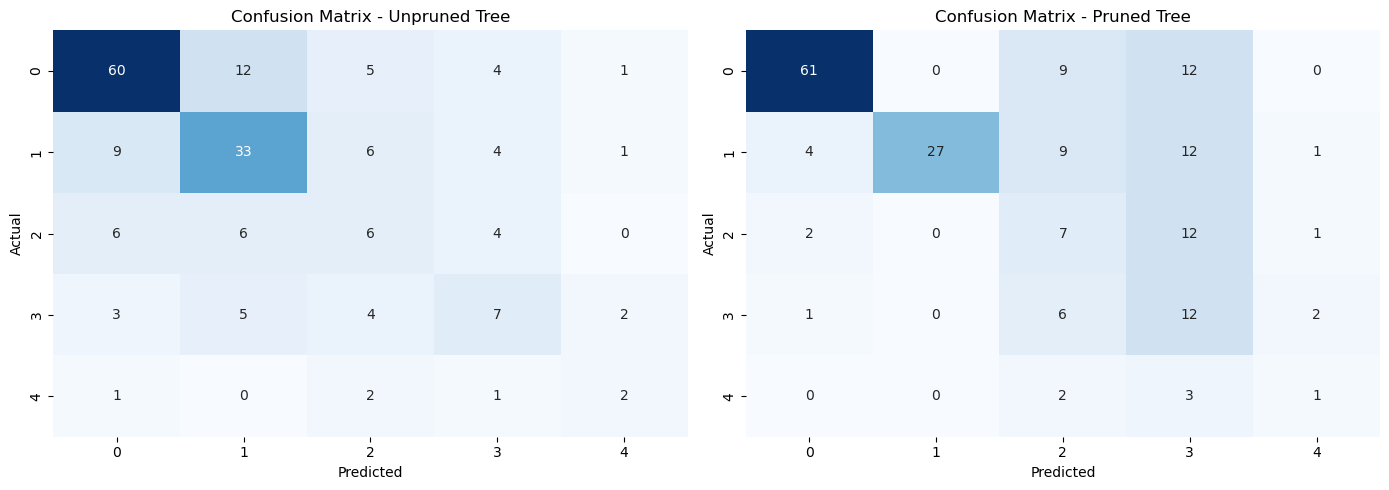

In [12]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

unpruned_cm = confusion_matrix(y_test, unpruned_preds)
pruned_cm = confusion_matrix(y_test, pruned_preds)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    unpruned_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0],
    cbar=False
)
ax[0].set_title("Confusion Matrix - Unpruned Tree")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels([0,1,2,3,4])
ax[0].set_yticklabels([0,1,2,3,4])

sns.heatmap(
    pruned_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1],
    cbar=False
)
ax[1].set_title("Confusion Matrix - Pruned Tree")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels([0,1,2,3,4])
ax[1].set_yticklabels([0,1,2,3,4])

plt.tight_layout()
plt.show()


### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

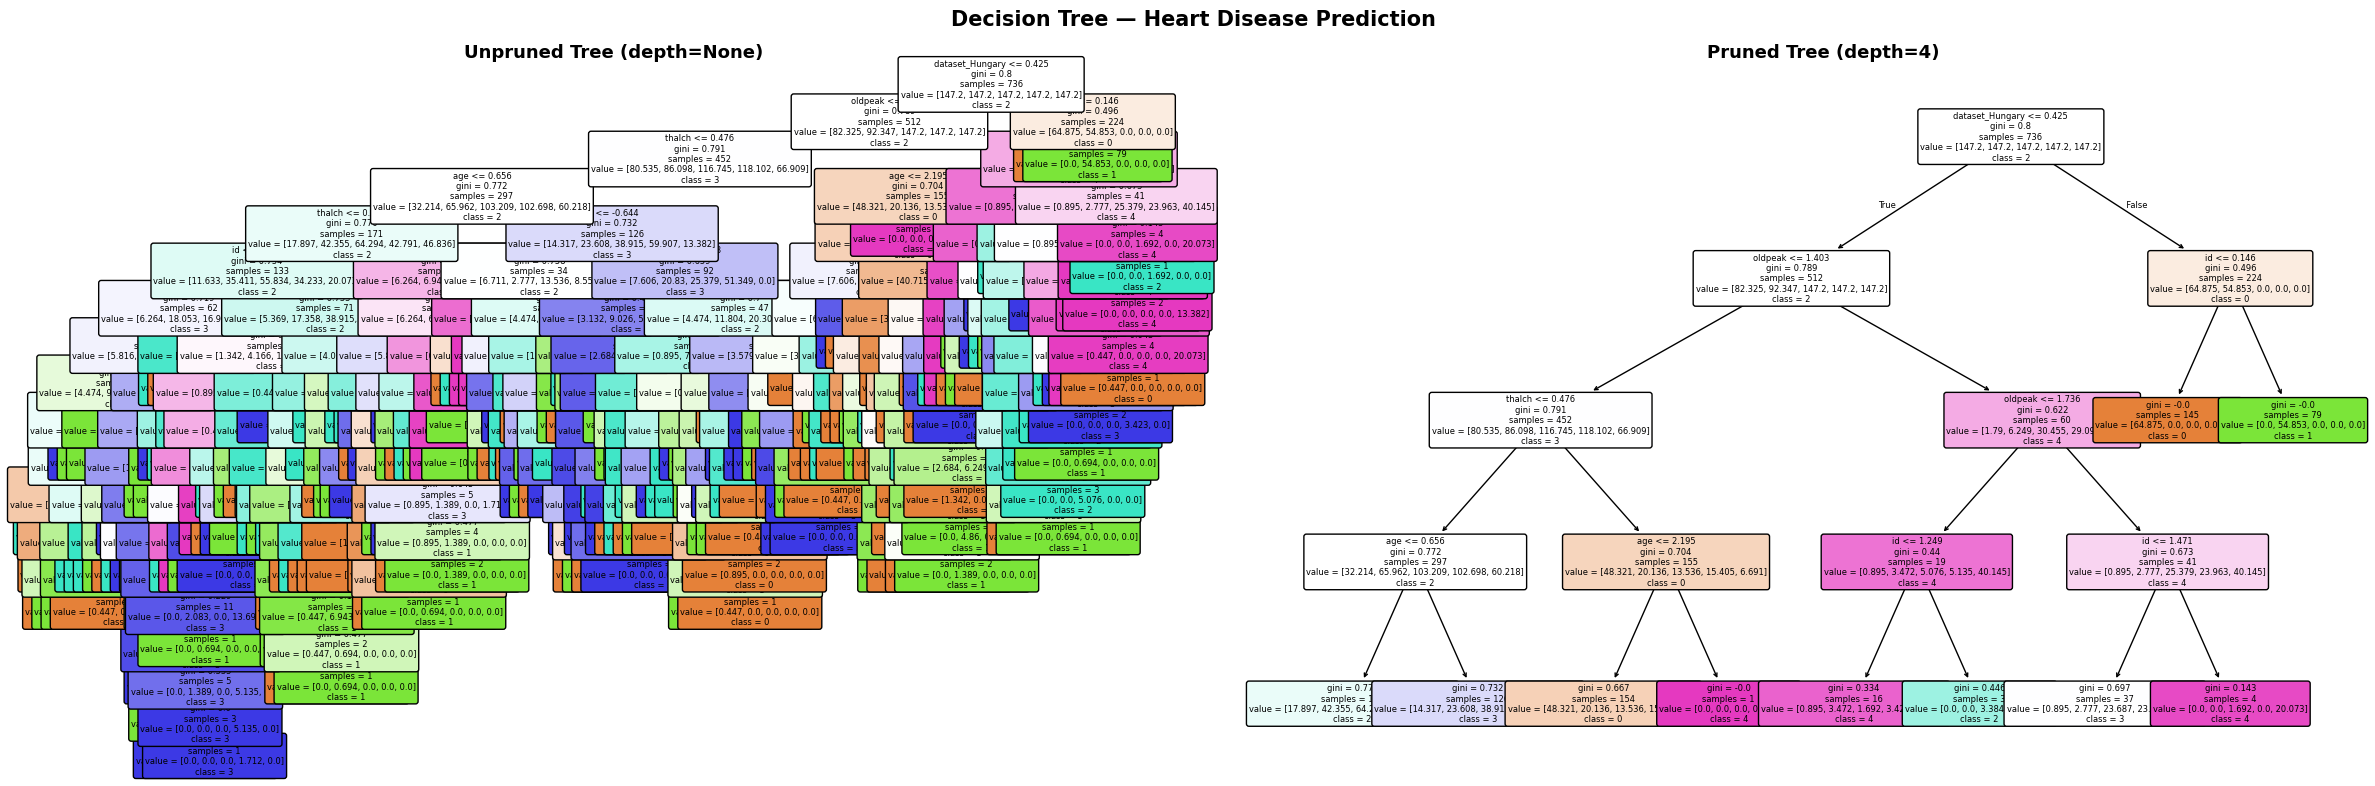

In [13]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

for ax, pipe, title in zip(
    axes,
    [tree_unpruned, tree_pruned],
    ['Unpruned Tree (depth=None)', 'Pruned Tree (depth=4)']
):
    plot_tree(
        pipe.named_steps['model'],
        feature_names=X_encoded.columns,
        class_names=[str(c) for c in sorted(y.unique())],
        filled=True,
        rounded=True,
        fontsize=6,
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Decision Tree — Heart Disease Prediction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

### Conclusion
- **Biggest takeaway:** Decision Trees are excellent for interpretability but require careful pruning to prevent overfitting.